## Importing Libraries

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

## Loading Model

In [2]:
model = tf.keras.models.load_model('tea_mobilenetv2_final.keras')

2026-08-19 01:31:22.440233: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-08-19 01:31:22.440250: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-08-19 01:31:22.440253: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-08-19 01:31:22.440265: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-19 01:31:22.440273: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,341,530 (20.38 MB)

 Trainable params: 1,536,648 (5.86 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,073,298 (11.72 MB)

## Visualising Single Image of Test set

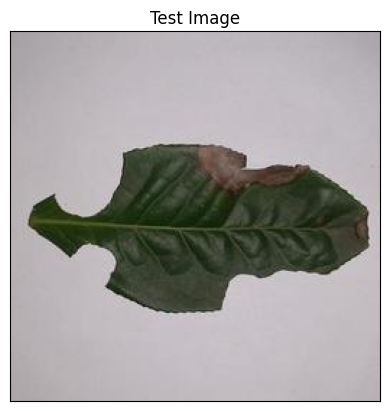

In [4]:
import cv2
image_path = 'test/gray light/20211226_002957.jpg'

# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) # Converting BGR to RGB

# Displaying the image 
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

## Testing Model

In [5]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
print(input_arr.shape)

(1, 128, 128, 3)


In [6]:
prediction = model.predict(input_arr)
prediction, prediction.shape

2026-08-19 01:31:23.747750: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


(array([[2.2919866e-09, 1.8239741e-07, 2.5869970e-12, 4.2192045e-05,
         9.9995756e-01, 1.2114494e-08, 9.1097081e-11, 9.9779915e-12]],
       dtype=float32),
 (1, 8))

In [7]:
pred_probs = prediction[0]
result_index = int(np.argmax(pred_probs))  # Return index of max element
confidence = float(pred_probs[result_index]) * 100

print(f"Predicted index: {result_index}")
print(f"Confidence: {confidence:.2f}%")

Predicted index: 4
Confidence: 100.00%


In [8]:
class_name = ['Anthracnose',
 'algal leaf',
 'bird eye spot',
 'brown blight',
 'gray light',
 'healthy',
 'red leaf spot',
 'white spot']

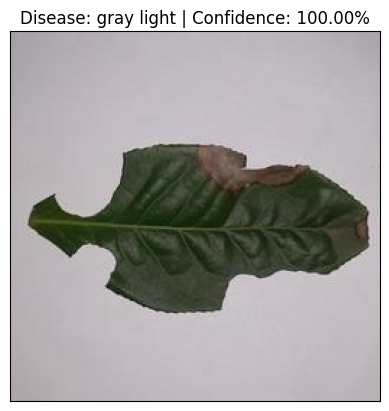

In [9]:
# Displaying disease prediction with confidence
model_prediction = class_name[result_index]

plt.imshow(img)
plt.title(f"Disease: {model_prediction} | Confidence: {confidence:.2f}%")
plt.xticks([])
plt.yticks([])
plt.show()